* check the thermalization and autocorrelations for the given parameters

* using the n_therm and the n_meas, look at the outputs of the nested sampling of CPN

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import glob

In [2]:
L, T = 72, 72
V = L*T

N = 21
beta = 0.6

n_cool_step = 50     # number of cooling steps 
meas_cool_every = 5
skip_topo = n_cool_step // meas_cool_every + 1

# action prefactor 
pf = 2#beta #*N*V

In [3]:
dir_list = sorted(glob.glob("/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000_fresh4/job_*"))
dir_list

['/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000_fresh4/job_16236075']

In [4]:
dir_list = sorted(glob.glob("/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/*")
                + glob.glob("/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000_fresh2/job_15985454/*")
                + glob.glob("/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000_fresh3/job_16235818/*")
                + glob.glob("/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000_fresh4/job_16236075/*"))

d0=0

gen_df  = "dati.dat"
topo_df = "topo.dat"
accr_df = "acceptance_rate.dat"
dir_list

['/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_0',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_1',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_2',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_3',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_4',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_5',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_6',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_7',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/job_15484566/run_8',
 '/scratch/network/users/lb25v444/out_data/ns_constraint_72_N21_10x5000_stoc5000/j

In [5]:
# for the long runs
n_live = 50
n_iter = len(dir_list)
print(n_iter)
n_live_eff = n_iter * n_live

40


In [6]:
""" 
the cols in the files are: 
gen_data:
    [0]: Conf. update index
    [1]: energy density S/(2NVb)
    [2]: magn_susc G(p=0)
    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)

topo_data:
    [0]: Conf. update index
    [1]: cooling step
    [2]: geom. top.charge Q_U
    [3]: geom. magn_susc_U
    [4]: geom. top.charge Q_z
    [5]: geom. magn_susc_z
    [6]: non-geom topo charge ~ plaquette
    [7]: non-geom topo susc ~ plaquette

    => was there a mixup? 
    [0]: Conf. update index
    [1]: cooling step
    [2]: geom. top.charge Q_U
    [3]: geom. top.charge Q_z
    [4]: non-geom topo charge ~ plaquette
    [5]: geom. magn_susc_U deriv
    [6]: geom. magn_susc_z deriv
    [7]: non-geom topo susc ~ plaquette deriv
"""

' \nthe cols in the files are: \ngen_data:\n    [0]: Conf. update index\n    [1]: energy density S/(2NVb)\n    [2]: magn_susc G(p=0)\n    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)\n\ntopo_data:\n    [0]: Conf. update index\n    [1]: cooling step\n    [2]: geom. top.charge Q_U\n    [3]: geom. magn_susc_U\n    [4]: geom. top.charge Q_z\n    [5]: geom. magn_susc_z\n    [6]: non-geom topo charge ~ plaquette\n    [7]: non-geom topo susc ~ plaquette\n\n    => was there a mixup? \n    [0]: Conf. update index\n    [1]: cooling step\n    [2]: geom. top.charge Q_U\n    [3]: geom. top.charge Q_z\n    [4]: non-geom topo charge ~ plaquette\n    [5]: geom. magn_susc_U deriv\n    [6]: geom. magn_susc_z deriv\n    [7]: non-geom topo susc ~ plaquette deriv\n'

# Load data into combined list

In [7]:
gen_data = []
topo_data = []
acc_rates = []

cutoff = -1 #8000

for d in dir_list[d0:]:
   cutoff = len(np.loadtxt(os.path.join(d,accr_df)))
   acc_rates.append(np.loadtxt(os.path.join(d,accr_df)))
   gen_data.append(np.loadtxt(os.path.join(d,gen_df))[:cutoff])
   topo_data.append(np.loadtxt(os.path.join(d,topo_df))[:cutoff*skip_topo]) 

In [8]:
gen_data  = np.concatenate(gen_data, axis=0)
topo_data = np.concatenate(topo_data, axis=0)
accr_data = np.concatenate(acc_rates, axis=0)

print(gen_data.shape, "\n", topo_data.shape, "\n", accr_data.shape)

(382210, 4) 
 (4204310, 8) 
 (382210, 4)


In [9]:
print(topo_data[::skip_topo].shape)

(382210, 8)


In [10]:
order = np.argsort(gen_data[:,1])[::-1]   # sort after the action vals, from largest to smallest

print(gen_data[:,1][order][:10])

[0.86757453 0.86716537 0.86620939 0.86593587 0.86574708 0.86547962
 0.86531604 0.86522672 0.86521149 0.86518854]


In [11]:
## for gen_data~[N, m], topo_data~[N*skip_topo, k]:
gen_sorted = gen_data[order]

# reshape topo_data into (N, skip_topo, k)
topo_blocks = topo_data.reshape(len(gen_data), skip_topo, -1)

# reorder the blocks
topo_sorted = topo_blocks[order]

# if needed, flatten back to the original shape
topo_sorted = topo_sorted.reshape(-1, topo_data.shape[1])

print(gen_sorted.shape, "\n", topo_sorted.shape)

(382210, 4) 
 (4204310, 8)


In [12]:
len(order)

382210

In [13]:
## for accr~[N, m]:
accr_sorted = accr_data[order[:len(accr_data)-1]]  #

print(accr_sorted.shape)

(382209, 4)


are we a little skewed because we did not stop?


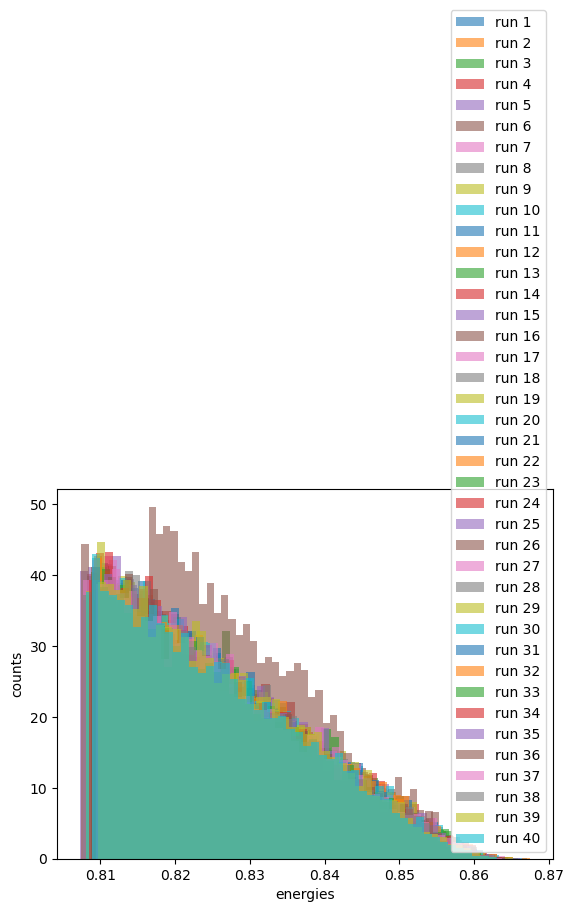

Text(0.5, 1.0, 'Combined energy list')

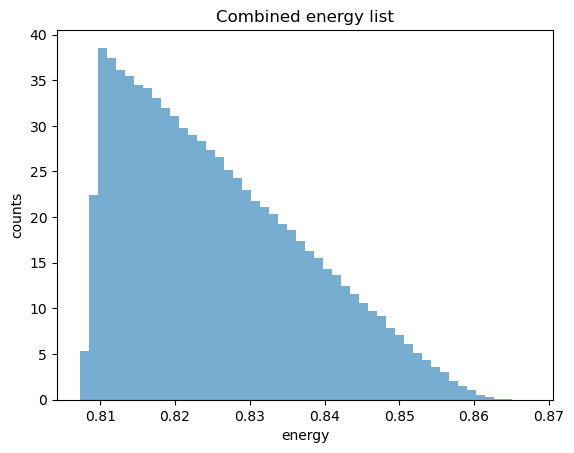

In [14]:
# look at different-run energies: => Achtugn, denisty=True!
run_nr = 1
for d in dir_list[d0:]:
   s = np.loadtxt(os.path.join(d,gen_df))[:,1]
   #s = s[:int(1*len(s)//2)]
   _=plt.hist(s, bins=50, alpha=0.6, label=f"run {run_nr}", density=True)
   run_nr += 1

plt.legend()
plt.xlabel("energies")
plt.ylabel("counts")

print("are we a little skewed because we did not stop?")
plt.show()

# at the sorted total run energy:
_=plt.hist(gen_sorted[:,1], bins=50, alpha=0.6, label=f"run {run_nr}", density=True)
plt.xlabel("energy")
plt.ylabel("counts")
plt.title("Combined energy list")

# acceptance rates

Text(0.5, 0, 'Nested sampling steps')

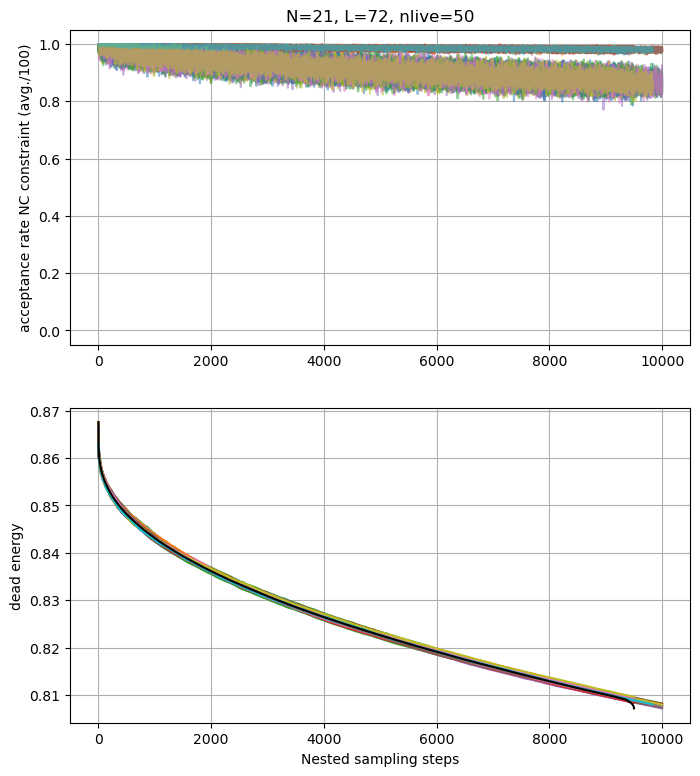

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(8, 9))

# look at different-run energies:
run_nr = 1
for d in dir_list[d0:]:
    data = np.loadtxt(os.path.join(d,accr_df))

    axs[0].plot(data[:,1], label=f"run {run_nr} single z", alpha=0.5)
    axs[0].plot(data[:,2], label=f"run {run_nr} single U", alpha=0.5)

    s = np.loadtxt(os.path.join(d,gen_df))

    axs[1].plot(s[:,1], label=f"run {run_nr}")

    run_nr += 1

axs[1].plot(np.linspace(0,1,len(gen_sorted))*len(s), gen_sorted[:,1], label=f"tot", color="black")    
    
axs[0].set_ylabel("acceptance rate NC constraint (avg./100)")
axs[0].grid()
#axs[0].legend()
axs[0].set_ylim(-0.05,1.05)

axs[1].set_ylabel("dead energy")
axs[1].grid()
#axs[1].legend()

axs[0].set_title("N=21, L=72, nlive=50")
axs[1].set_xlabel("Nested sampling steps")

# look at data

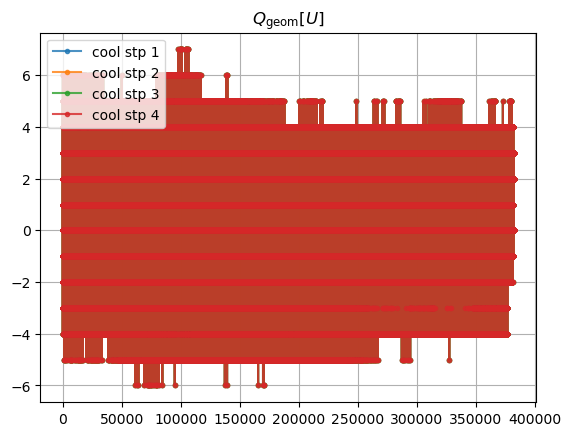

(-5.0, 5.0)

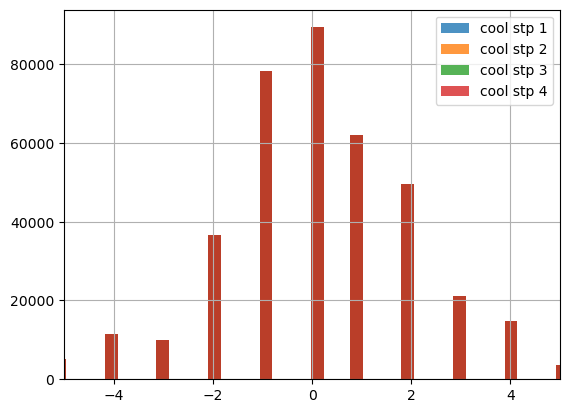

In [16]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, bins=50, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.xlim(-5,5)

Text(0.5, 0, 'sample nr.')

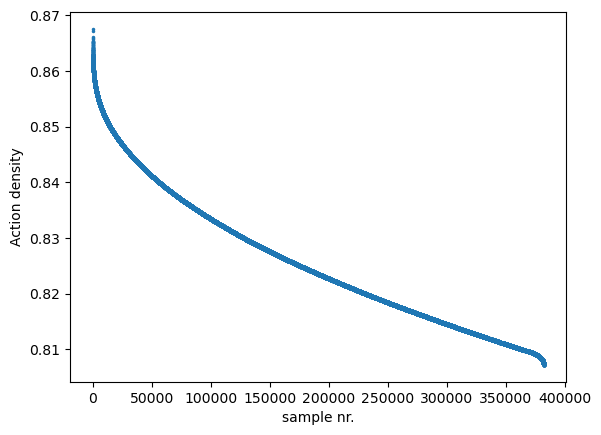

In [17]:
# progression of the action values?
plt.plot(gen_sorted[::,1], marker=".", linestyle="", ms=3)

#plt.xlim(0, 100)

plt.ylabel("Action density")
plt.xlabel("sample nr.")

# look at nested sampling Z

In [18]:
gen_data  = gen_sorted
topo_data = topo_sorted

energies = 2*gen_data[:,1]

print(gen_data.shape, "\n", topo_data.shape)

(382210, 4) 
 (4204310, 8)


In [19]:
n_meas = len(gen_data)
print(n_meas)

382210


In [20]:
# similar to Simone Romiti's lattice tools: https://github.com/simone-romiti/lattice_data_tools/tree/main

# get set of Beta-distributed vals X_i
# rng = np.random.default_rng()
#t_list = rng.beta(n_live, 1, size=(n_meas,))
# x_list = np.cumprod(t_list)

## simple approach:
log_t = (-1.0/n_live_eff) * np.ones(n_meas)
t_list = np.exp(log_t)

# get log(x)
log_x = np.cumsum(log_t)
x_list = np.exp(log_x)
h_list = np.exp(log_x[:-1]) - np.exp(log_x[1:])
#print(log_x.shape)

# get log(w) (fwd definition ~ w_i = x_i-1 - x_i)
log_w = log_x  + np.log(1.0 - t_list)

In [21]:
# alternatively:
log_X_before = np.arange(n_meas) * log_t
log_w = log_X_before + np.log1p(-np.exp(log_t))

In [22]:
# get log(w)
"""log_w0 = 0
log_w = [np.log(1-t_list[0])]
for i in range(1, len(t_list-1)):
    log_w0 += np.log(t_list[i-1])
    log_w.append(log_w0-np.log(1-t_list[i]))

log_w = np.array(log_w)"""

'log_w0 = 0\nlog_w = [np.log(1-t_list[0])]\nfor i in range(1, len(t_list-1)):\n    log_w0 += np.log(t_list[i-1])\n    log_w.append(log_w0-np.log(1-t_list[i]))\n\nlog_w = np.array(log_w)'

In [23]:
from scipy.special import logsumexp

In [24]:
# get normalized weights: (L=1 here since it is part of the prior!)
log_Z_unnorm = logsumexp(log_w)
log_w_norm = log_w - log_Z_unnorm

In [25]:
# from Simones tools:
def get_log_Z_curve(log_wL_normalized: np.ndarray):
    """
    The partition function is normalized to 1.
    The total weights w_i*L_i are the discrete version of the probability density function.
    The cumulative sum of the total weights gives use the cumulative density function. This function returns the log of that curve.
    """
    n_iter = log_wL_normalized.shape[0]
    s = log_wL_normalized[0]
    logZ = [s]
    for i in range(n_iter-1):
        s = np.logaddexp(s, log_wL_normalized[i+1])
        logZ.append(s)
    #---
    res = np.array(logZ)
    return res

Text(0, 0.5, 'Z')

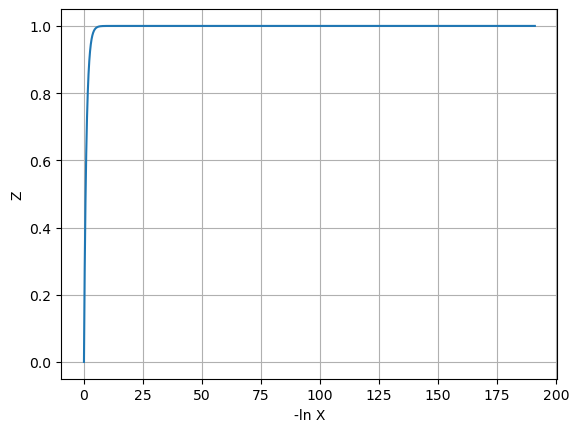

In [26]:
log_Z_curve = get_log_Z_curve(log_w_norm)
plt.plot(-log_x,np.exp(log_Z_curve))

plt.grid()
plt.xlabel("-ln X")
plt.ylabel("Z")

In [27]:
# does it do the same as the function above? yes!
log_Z = []
for i in range(len(energies)):
    log_Z.append(logsumexp(log_w[:i]))  #-energies[:i]+
log_Z = np.array(log_Z)
log_Z_norm = log_Z[-1]
log_Z -= log_Z_norm
log_Z.shape
# log_Z_tot = logsumexp(-energies+log_w)

(382210,)

Text(0, 0.5, 'Z')

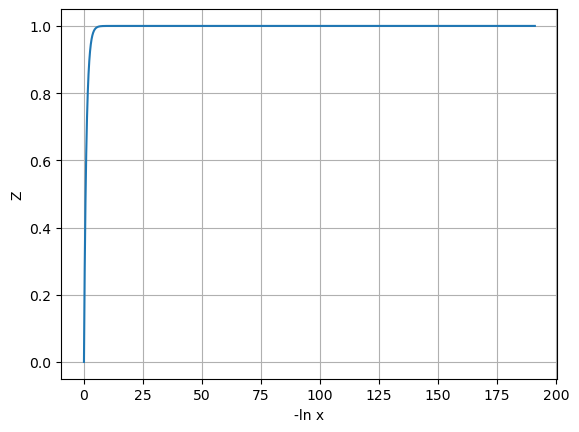

In [28]:
plt.plot(-np.log(x_list[:]), np.exp(log_Z))       #
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("Z")

In [29]:
log_Z = []
for i in range(len(energies)):
    log_Z.append(logsumexp(log_w_norm[:i]))  #-energies[:i]+
log_Z = np.array(log_Z)
log_Z.shape
# log_Z_tot = logsumexp(-energies+log_w)

(382210,)

Text(0, 0.5, 'norm. weights')

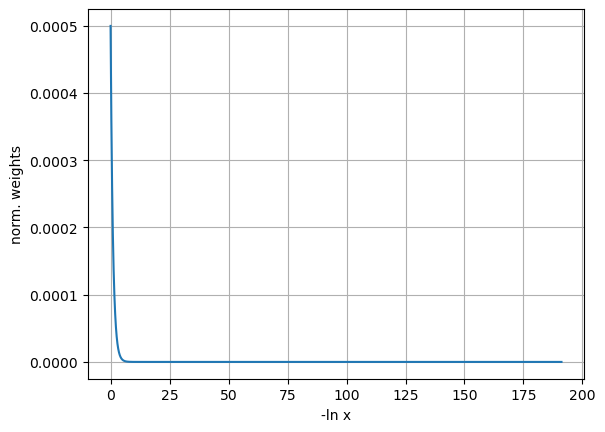

In [30]:
plt.plot(-np.log(x_list[:]),np.exp(log_w_norm))
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("norm. weights")

Text(0, 0.5, 'Z')

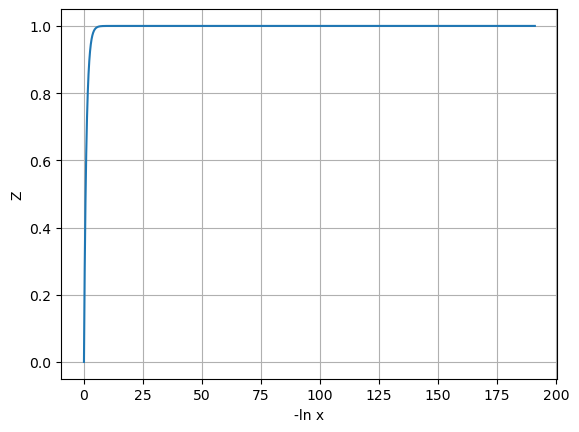

In [31]:
plt.plot(-np.log(x_list[:]), np.exp(log_Z))       #
plt.grid()
plt.xlabel("-ln x")
plt.ylabel("Z")

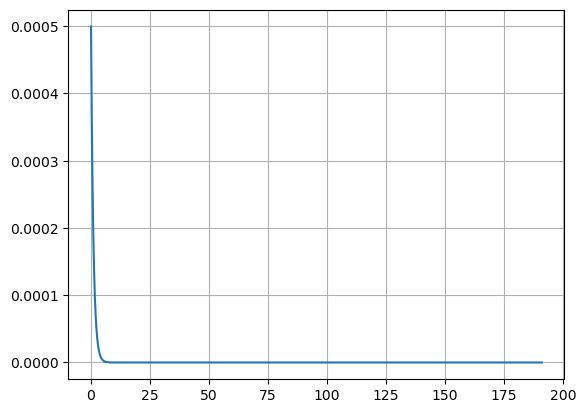

In [32]:
plt.plot(-np.log(x_list[1:]), h_list)       #np.exp(Z_can)*
plt.grid()

# look at the energy
$$ 
    \langle O \rangle = \frac{1}{Z}\sum_i L_i^{\Delta\beta} w_i O_i
$$

Text(0, 0.5, 'counts')

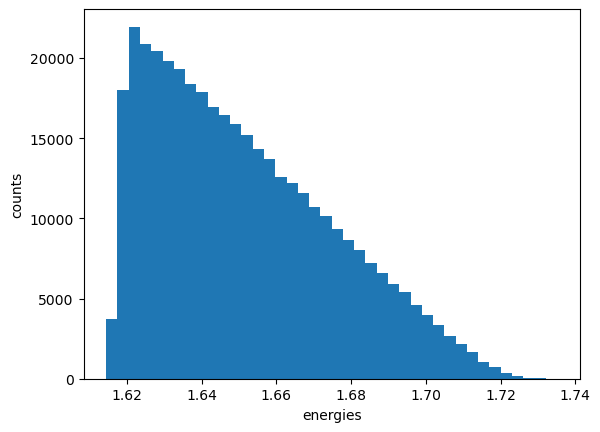

In [33]:
energies = 2*gen_data[:,1]
_=plt.hist(energies, bins=40)
plt.xlabel("energies")
plt.ylabel("counts")

In [34]:
# avg_obs = np.sum(np.exp(log_w_norm)*energies)
avg_obs = np.sum(np.exp(log_w_norm+np.log(energies)))
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t1.716722(2)")

1.7165789426688598
Thesis result for b=0.6, L=72, N=21:	1.716722(2)


1.716910183283351
Thesis result for b

first two runs: 1.716910183283351

# Look at the geometric cooled charge

Can we also get the correct $\langle Q^2 \rangle?

[2]: geom. top.charge Q_U
[3]: geom. top.charge Q_z
[4]: non-geom topo charge ~ plaquette

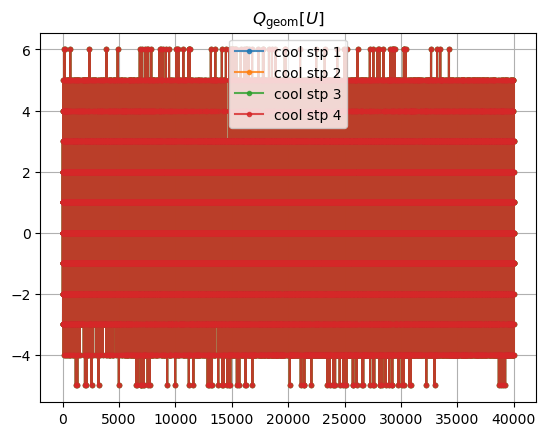

(-5.0, 5.0)

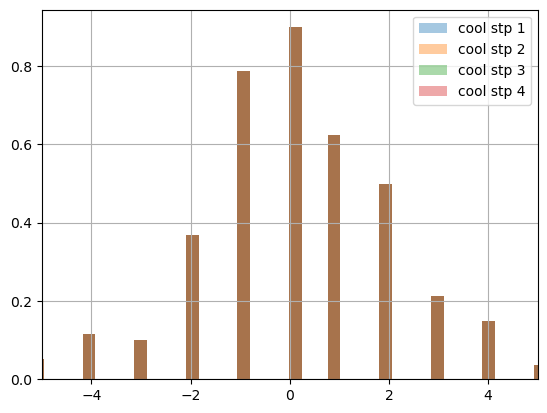

In [35]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
topo_idx = 2
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,topo_idx][:40000], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,topo_idx][:], alpha=0.4, bins=50, label=f"cool stp {cool_stp}", density=True)
plt.grid()
plt.legend()
plt.xlim(-5,5)

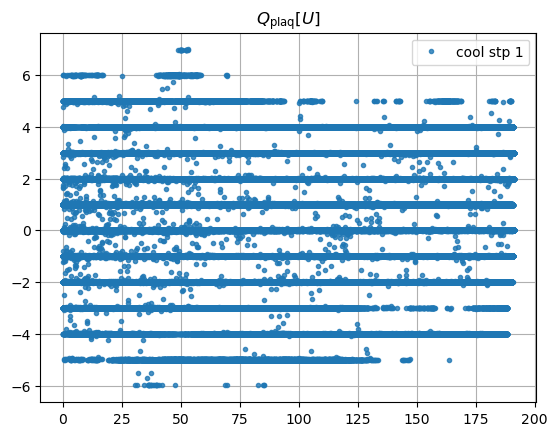

In [36]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
topo_idx = 4

plt.plot(-np.log(x_list[:]), topo_sorted[cool_stp::skip_topo,topo_idx][:], alpha=0.8, marker="o", linestyle="None", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{plaq}[U]$")
plt.show()

In [37]:
c_step = 4
obs = topo_data[c_step::skip_topo,2]

avg_obs = np.sum(np.exp(log_w_norm)*obs)
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t0.002(3)")
print("This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!")

avg_obs2 = np.sum(np.exp(log_w_norm)*(obs**2))
print("<Q^2>:\t", avg_obs2)

0.34735751248215
Thesis result for b=0.6, L=72, N=21:	0.002(3)
This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!
<Q^2>:	 3.4297952259961875


In [38]:
# compare with different equation ansatz:
avg_obs = np.sum(np.sign(obs)*np.exp(log_w_norm+np.log(np.abs(obs))))
print(avg_obs)

print("Thesis result for b=0.6, L=72, N=21:\t0.002(3)")
print("This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!")

avg_obs2 = np.sum(np.exp(log_w_norm+np.log(np.abs(obs))*2))

print("<Q^2>:\t", avg_obs2)

0.34735751248214997
Thesis result for b=0.6, L=72, N=21:	0.002(3)
This is perhaps skewed by the fact that we are in the end trapped in one topological sector...!
<Q^2>:	 3.4297952259961875


/scratch/local/16793984/ipykernel_176084/872623572.py:2: RuntimeWarning: divide by zero encountered in log
  avg_obs = np.sum(np.sign(obs)*np.exp(log_w_norm+np.log(np.abs(obs))))
/scratch/local/16793984/ipykernel_176084/872623572.py:8: RuntimeWarning: divide by zero encountered in log
  avg_obs2 = np.sum(np.exp(log_w_norm+np.log(np.abs(obs))*2))


In [39]:
chi_L = (avg_obs2 - avg_obs**2) / V
print(chi_L)

0.0006383368025691359


# Look at $\xi_L$

And what about the correlation length? 

$$
\xi_L^2 = \frac{1}{4\sin^2(k/2)} \left[ \frac{\tilde{G}_L(0)}{\tilde{G}_L(k)} - 1\right] , \ \ k= 2\pi/L
$$

Some of the G_L are negative? Should that be allowed?

In [40]:
k = 2*np.pi / L

In [41]:
obs_0 = gen_data[:,2]
obs_k = gen_data[:,3]

#avg_obs_0 = np.sum(np.exp(log_w_norm)*obs_0)
#avg_obs_k = np.sum(np.exp(log_w_norm)*obs_k)

avg_obs_0 = np.sum(np.sign(obs_0)*np.exp(log_w_norm+np.log(np.abs(obs_0))))
avg_obs_k = np.sum(np.sign(obs_k)*np.exp(log_w_norm+np.log(np.abs(obs_k))))

xi_L2 = 1 / (4 * np.sin(k/2)**2) * (avg_obs_0/avg_obs_k - 1.)
print(f"xi_L={np.sqrt(xi_L2)}")

print("Thesis result for b=0.6, L=72, N=21:\t2.895(7)")

xi_L=2.4565564217515714
Thesis result for b=0.6, L=72, N=21:	2.895(7)


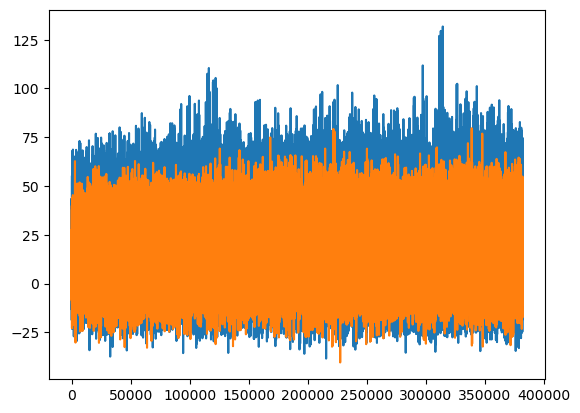

In [42]:
plt.plot(obs_0)
plt.plot(obs_k)

# $V \cdot \chi_L$ and $\chi_L \xi_L^2$?

In [43]:
print(V * chi_L)
print("Thesis result for b=0.6, L=72, N=21:\t4.943(8)")

3.309137984518401
Thesis result for b=0.6, L=72, N=21:	4.943(8)


In [44]:
chi_L * xi_L2 * 1000    # why is there a factor ~2 missing?

3.852151603348528